In [114]:
from google.colab import files
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from sklearn.neighbors import NearestNeighbors

In [115]:
# upload the txt file
uploaded = files.upload()

Saving circles.txt to circles (2).txt


In [116]:
df = pd.read_csv("circles.txt")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       10000 non-null  float64
 1   y       10000 non-null  float64
 2   class   10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [117]:
df.head(6)

,x,y,class
0,3.15676,116.12252,6
1,16.14436,16.81660,11
2,100.31212,64.99025,53
3,-1.33773,84.81772,4
4,104.37328,62.42373,53
5,178.50482,95.22879,95


In [118]:
# Checking for missing values
df.isnull().sum()

,0
x,0
y,0
class,0


In [119]:
# Summary Statistic
df.describe()

,x,y,class
count,10000.000000,10000.000000,10000.000000
mean,89.981670,90.003827,49.500000
std,57.457467,57.559719,28.867513
min,-5.000000,-4.999860,0.000000
25%,40.237885,40.133840,24.750000
50%,89.999995,90.000080,49.500000
75%,139.898800,139.977695,74.250000
max,184.999920,185.000000,99.000000


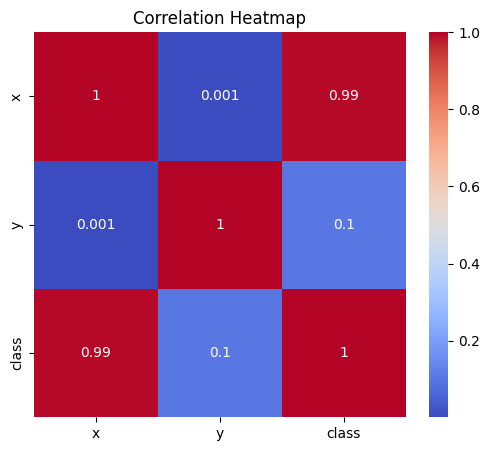

In [120]:
# Correlation matrix
corr = df.corr()

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

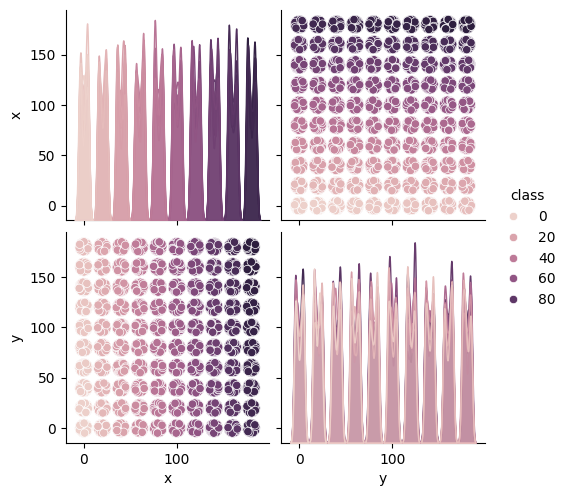

In [121]:
# Pair plot
sns.pairplot(df, hue='class')
plt.show()

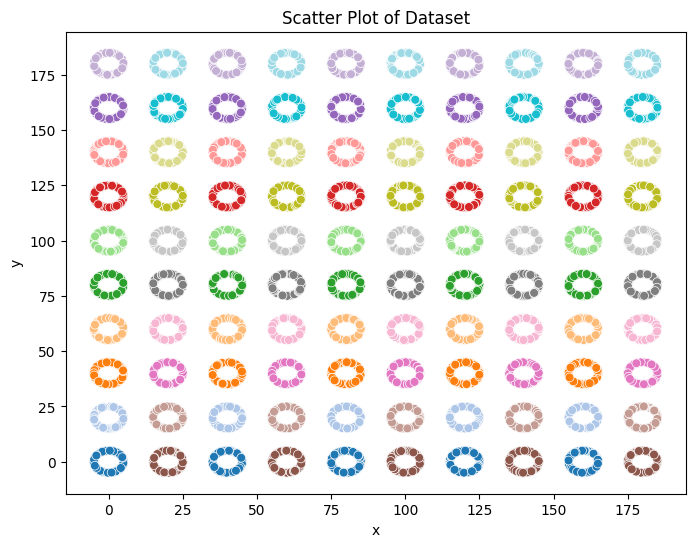

In [122]:
# Scatter plot of raw data
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue='class',
    palette='tab20',
    s=40
)

plt.title("Scatter Plot of Dataset")
plt.xlabel("x")
plt.ylabel("y")

# Remove legend since classes are many
plt.legend([], [], frameon=False)

plt.show()

In [123]:
# Features for clustering
X = df[['x', 'y']]
y_true = df["class"].values
print(X.head(6))
print(y_true[:6])

           x          y
0    3.15676  116.12252
1   16.14436   16.81660
2  100.31212   64.99025
3   -1.33773   84.81772
4  104.37328   62.42373
5  178.50482   95.22879
[ 6 11 53  4 53 95]


In [124]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.51119178  0.45378954]
 [-1.28514197 -1.27156435]
 [ 0.17980199 -0.43458913]
 [-1.5894186  -0.0901041 ]
 [ 0.25048667 -0.47918018]]


In [125]:
# PCA (Although with 2 features there is no dimensionality reduction)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:", explained_variance)
print("PC1 explains:", round(explained_variance[0] * 100, 2), "%")
print("PC2 explains:", round(explained_variance[1] * 100, 2), "%")
print("Total variance:", round(sum(explained_variance) * 100, 2), "%")

Explained Variance Ratio: [0.50050531 0.49949469]
PC1 explains: 50.05 %
PC2 explains: 49.95 %
Total variance: 100.0 %


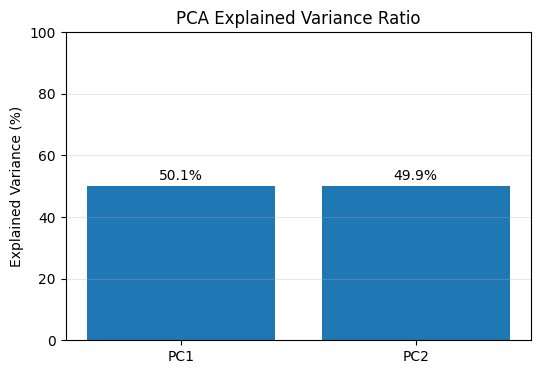

In [126]:
#Visualize the variance

plt.figure(figsize=(6,4))

plt.bar(
    ['PC1', 'PC2'],
    explained_variance * 100
)

plt.ylabel("Explained Variance (%)")
plt.title("PCA Explained Variance Ratio")
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(explained_variance):
    plt.text(i, v * 100 + 2, f"{v*100:.1f}%", ha='center')

plt.show()

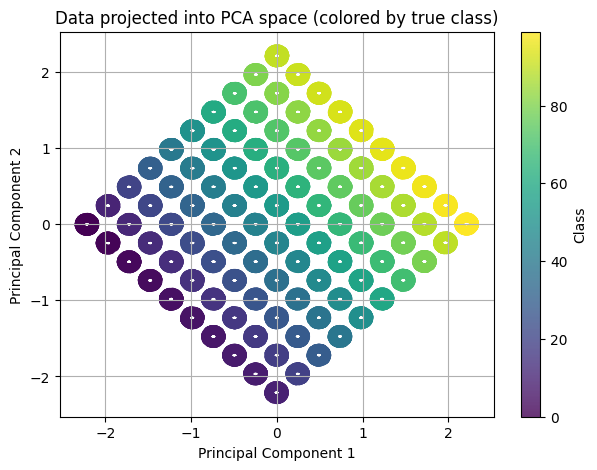

In [127]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_true,
    cmap='viridis',
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Data projected into PCA space (colored by true class)")
plt.colorbar(scatter, label="Class")
plt.grid(True)
plt.show()

**K-Means**

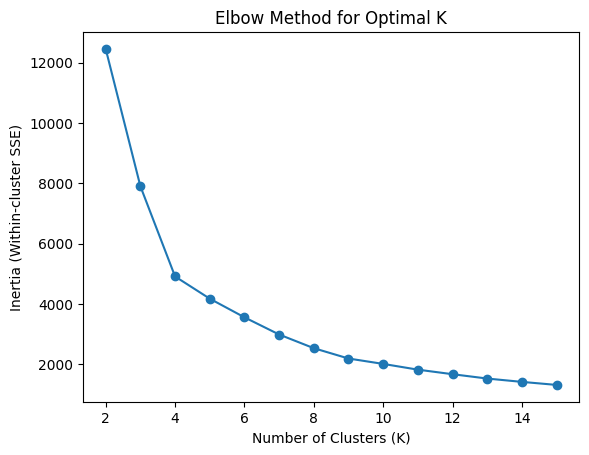

In [128]:
#Elbow method(Choosing K)

inertia = []
k_range = range(2, min(15, len(X)) + 1)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal K")
plt.show()

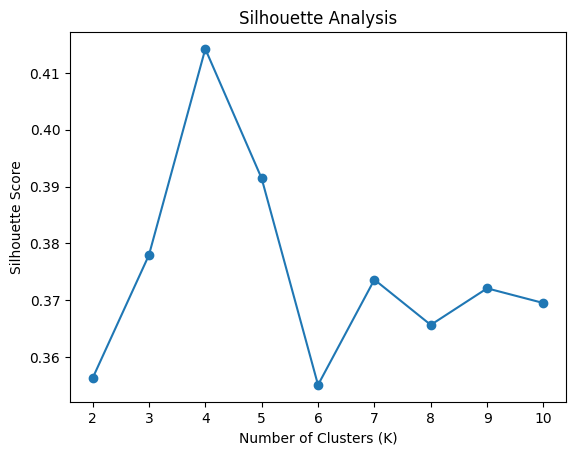

In [129]:
# Silhouette Score
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [130]:
#Select best K

best_k = list(k_range)[np.argmax(sil_scores)]

print("Best K based on silhouette score:", best_k)

#Fit final K
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
df["cluster"] = final_kmeans.fit_predict(X_scaled)

Best K based on silhouette score: 4


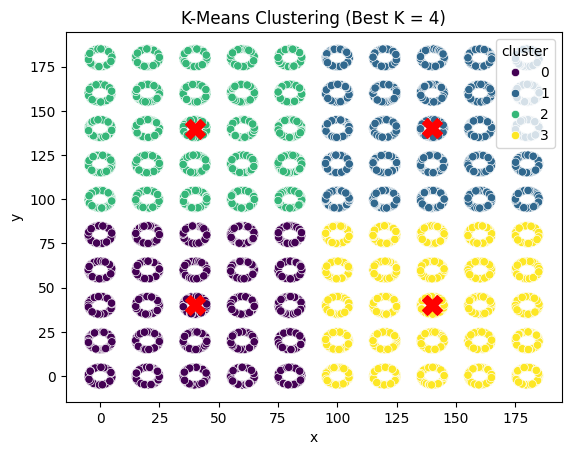

In [131]:
# Cluster centroid
centroids_original = scaler.inverse_transform(final_kmeans.cluster_centers_)

sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="viridis")

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=200,
    c="red",
    marker="X"
)

plt.title(f"K-Means Clustering (Best K = {best_k})")
plt.show()

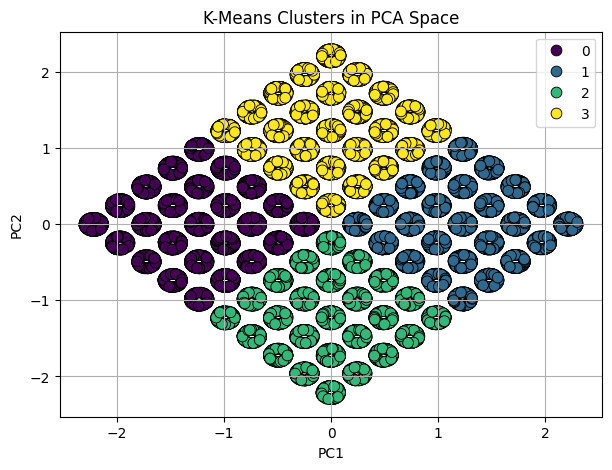

In [142]:
#K-Means Clusters in PCA Space
k_labels = df["cluster"].values
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=k_labels,
    palette="viridis",
    s=60,
    edgecolor="black"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")
plt.grid(True)
plt.show()

In [143]:
# =========================
# K-MEANS EVALUATION
# =========================

mask = k_labels != -1
KX_eval = X_scaled[mask]
k_labels_eval = k_labels[mask]

# Internal Metrics
k_sil_score = silhouette_score(KX_eval, k_labels_eval)
k_db_index = davies_bouldin_score(KX_eval, k_labels_eval)
k_ch_score = calinski_harabasz_score(KX_eval, k_labels_eval)

# External Metrics
k_ari = adjusted_rand_score(y_true, k_labels)
k_nmi = normalized_mutual_info_score(y_true, k_labels)

print("\n=== K-MEANS METRICS ===")
print(f"Silhouette Score:        {k_sil_score:.4f}")
print(f"Davies-Bouldin Index:    {k_db_index:.4f}")
print(f"Calinski-Harabasz Index: {k_ch_score:.4f}")
print("========================")
print(f"Adjusted Rand Index:     {k_ari:.4f}")
print(f"Normalized Mutual Info:  {k_nmi:.4f}")


=== K-MEANS METRICS ===
Silhouette Score:        0.4142
Davies-Bouldin Index:    0.7585
Calinski-Harabasz Index: 10224.6522
Adjusted Rand Index:     0.0583
Normalized Mutual Info:  0.4628


**Hierarchical**

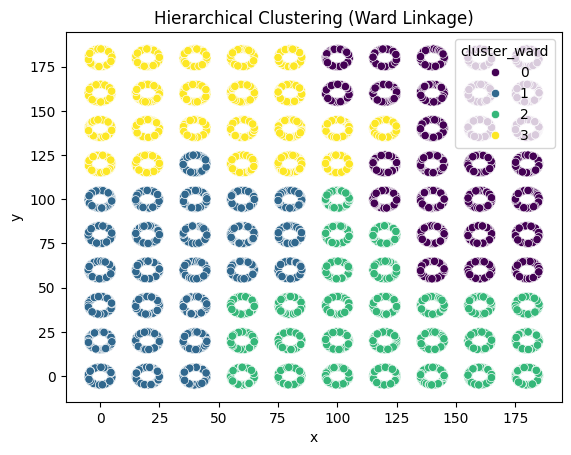

In [144]:
hc_ward = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

df["cluster_ward"] = hc_ward.fit_predict(X_scaled)

import seaborn as sns

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="cluster_ward",
    palette="viridis"
)

plt.title("Hierarchical Clustering (Ward Linkage)")
plt.show()

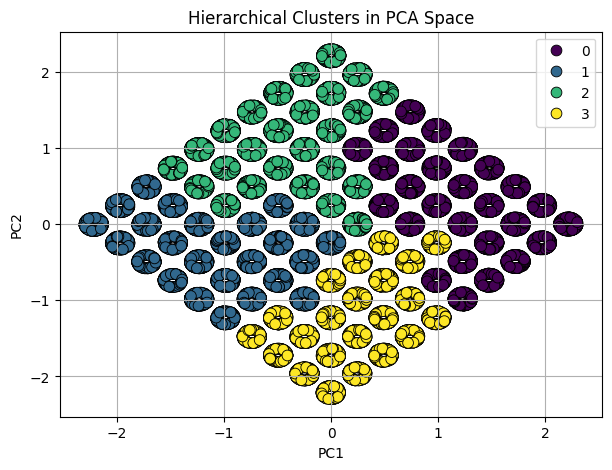

In [145]:
#Hierarchical Clusters in PCA Space
h_labels = df["cluster_ward"].values

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=h_labels,
    palette="viridis",
    s=60,
    edgecolor="black"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters in PCA Space")
plt.grid(True)
plt.show()

In [146]:
# =========================
# HIERARCHICAL EVALUATION
# =========================

h_labels = df["cluster_ward"].values

h_mask = h_labels != -1
h_X_eval = X_scaled[h_mask]
h_labels_eval = h_labels[h_mask]

# Internal Metrics
h_sil_score = silhouette_score(h_X_eval, h_labels_eval)
h_db_index = davies_bouldin_score(h_X_eval, h_labels_eval)
h_ch_score = calinski_harabasz_score(h_X_eval, h_labels_eval)

# External Metrics
h_ari = adjusted_rand_score(y_true, h_labels)
h_nmi = normalized_mutual_info_score(y_true, h_labels)

print("\n=== HIERARCHICAL CLUSTERING METRICS ===")
print(f"Silhouette Score:        {h_sil_score:.4f}")
print(f"Davies-Bouldin Index:    {h_db_index:.4f}")
print(f"Calinski-Harabasz Index: {h_ch_score:.4f}")
print("==============================")
print(f"Adjusted Rand Index:     {h_ari:.4f}")
print(f"Normalized Mutual Info:  {h_nmi:.4f}")



=== HIERARCHICAL CLUSTERING METRICS ===
Silhouette Score:        0.3338
Davies-Bouldin Index:    0.8923
Calinski-Harabasz Index: 7660.9384
Adjusted Rand Index:     0.0579
Normalized Mutual Info:  0.4620


**DBSCAN**

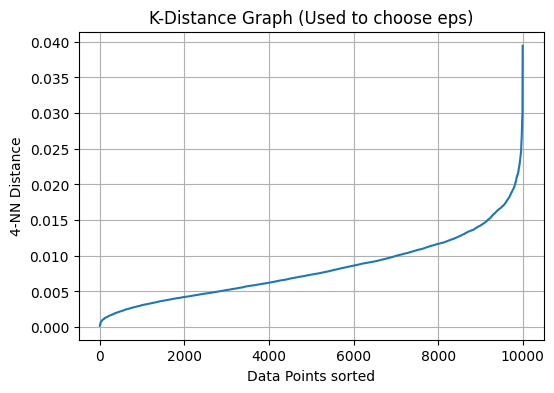

In [147]:
#min_samples = 2 * number_of_features(2)
min_samples = 4
k = min_samples

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# sort distances to k-th nearest neighbor
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Data Points sorted")
plt.ylabel(f"{k}-NN Distance")
plt.title("K-Distance Graph (Used to choose eps)")
plt.grid(True)
plt.show()

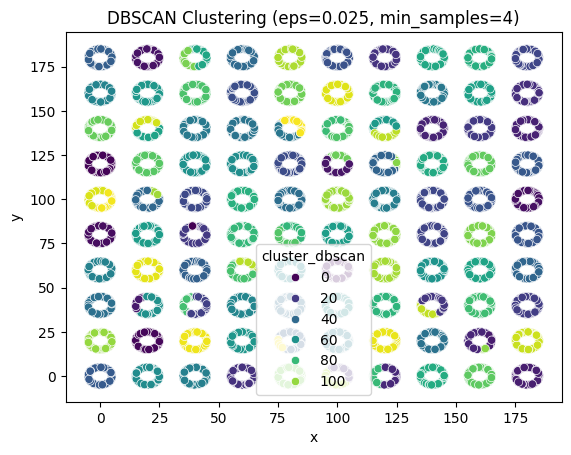

In [148]:
eps = 0.025
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric="euclidean"
)

df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="cluster_dbscan",
    palette="viridis"
)

plt.title(f"DBSCAN Clustering (eps={eps}, min_samples={min_samples})")
plt.show()

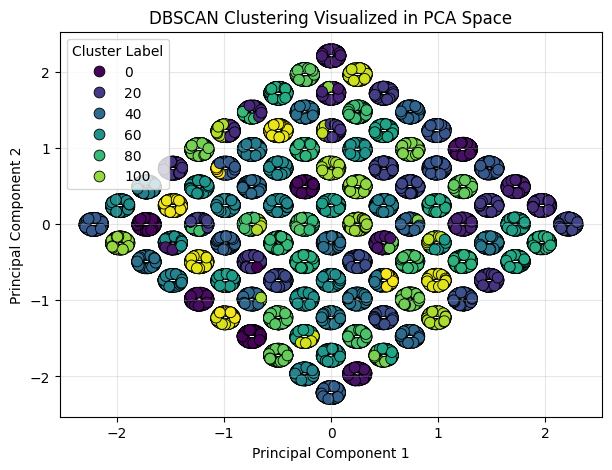

In [149]:
#DBSCAN clustering visualization in PCA space
db_labels = df["cluster_dbscan"].values

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=db_labels,
    palette="viridis",
    s=60,
    edgecolor="black"
)

plt.title("DBSCAN Clustering Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Label")
plt.grid(True, alpha=0.3)

plt.show()

In [150]:
# =========================
# DBSCAN EVALUATION
# =========================

db_labels = df["cluster_dbscan"].values

db_mask = db_labels != -1

db_X_eval = X_scaled[db_mask]
db_labels_eval = db_labels[db_mask]

print("\n=== DBSCAN METRICS ===")

# Internal Metrics
if len(set(db_labels_eval)) < 2:
    print("Not enough clusters after removing noise.")
else:
    db_sil_score = silhouette_score(db_X_eval, db_labels_eval)
    db_db_index = davies_bouldin_score(db_X_eval, db_labels_eval)
    db_ch_score = calinski_harabasz_score(db_X_eval, db_labels_eval)

    print(f"Silhouette Score:        {db_sil_score:.4f}")
    print(f"Davies-Bouldin Index:    {db_db_index:.4f}")
    print(f"Calinski-Harabasz Index: {db_ch_score:.4f}")
    print("=====================================")

# External Metrics
db_ari = adjusted_rand_score(y_true, db_labels)
db_nmi = normalized_mutual_info_score(y_true, db_labels)

print(f"Adjusted Rand Index:     {db_ari:.4f}")
print(f"Normalized Mutual Info:  {db_nmi:.4f}")


=== DBSCAN METRICS ===
Silhouette Score:        0.5603
Davies-Bouldin Index:    0.6661
Calinski-Harabasz Index: 23902.4035
Adjusted Rand Index:     0.9540
Normalized Mutual Info:  0.9866


**Comparative Analysis Table**

In [151]:
import pandas as pd

# =========================
# COMBINE ALL RESULTS
# =========================

results_df = pd.DataFrame({

    "K-Means": {
        "Silhouette Score": k_sil_score,
        "Davies-Bouldin Index": k_db_index,
        "Calinski-Harabasz Index": k_ch_score,
        "Adjusted Rand Index (ARI)": k_ari,
        "Normalized Mutual Info (NMI)": k_nmi
    },

    "Hierarchical": {
        "Silhouette Score": h_sil_score,
        "Davies-Bouldin Index": h_db_index,
        "Calinski-Harabasz Index": h_ch_score,
        "Adjusted Rand Index (ARI)": h_ari,
        "Normalized Mutual Info (NMI)": h_nmi
    },

    "DBSCAN": {
        "Silhouette Score": db_sil_score if 'db_sil_score' in locals() else None,
        "Davies-Bouldin Index": db_db_index if 'db_db_index' in locals() else None,
        "Calinski-Harabasz Index": db_ch_score if 'db_ch_score' in locals() else None,
        "Adjusted Rand Index (ARI)": db_ari,
        "Normalized Mutual Info (NMI)": db_nmi
    }

}).T

# Round values for cleaner display
results_df = results_df.round(4)

# Display table
display(results_df)

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Adjusted Rand Index (ARI),Normalized Mutual Info (NMI)
K-Means,0.4142,0.7585,10224.6522,0.0583,0.4628
Hierarchical,0.3338,0.8923,7660.9384,0.0579,0.4620
DBSCAN,0.5603,0.6661,23902.4035,0.9540,0.9866
